<a href="https://colab.research.google.com/github/Soco-Roman/GISLatam_2026/blob/main/Exercise_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Quantifying Cyclist Safety: Exposure and Risk Index Modeling

This notebook performs the calculation of a cyclist risk index based on urban infrastructure, the concentration of traffic incidents and trip-attractor points. The exercise maps the highest-risk road segments using a specialized color scale, enabling the identification of key roads for the implementation of urban policies.

In [44]:
# Install all necessary geospatial libraries
!pip install osmnx contextily matplotlib-scalebar

## Spatial Analysis for Mexico City

In [46]:
# 1. Import Libraries
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
from sklearn.preprocessing import MinMaxScaler
import mapclassify
import contextily as ctx
import numpy as np

### Step 1: Install Libraries (Run this cell, then restart runtime, then run all cells)

### Step 1: Load Data
Loading the local GeoJSON files into GeoDataFrames.

In [47]:
infra_ciclista = gpd.read_file('/content/infra_ciclista.geojson')
vialidades_cdmx = gpd.read_file('/content/vialidades_cdmx.geojson')
atus_cdmx = gpd.read_file('/content/atus_cdmx.geojson')

print("Data loaded successfully.")
print(f"Infra Ciclista CRS: {infra_ciclista.crs}")
print(f"Vialidades CDMX CRS: {vialidades_cdmx.crs}")
print(f"ATUS CDMX CRS: {atus_cdmx.crs}")

Data loaded successfully.
Infra Ciclista CRS: EPSG:32614
Vialidades CDMX CRS: EPSG:32614
ATUS CDMX CRS: EPSG:4326


### Step 2: Reprojection
Converting the Coordinate Reference System (CRS) of all three GeoDataFrames to Web Mercator (EPSG:3857).

In [48]:
target_crs = 'EPSG:3857'

infra_ciclista = infra_ciclista.to_crs(target_crs)
vialidades_cdmx = vialidades_cdmx.to_crs(target_crs)
atus_cdmx = atus_cdmx.to_crs(target_crs)

print(f"All GeoDataFrames reprojected to {target_crs}.")
print(f"Infra Ciclista CRS: {infra_ciclista.crs}")
print(f"Vialidades CDMX CRS: {vialidades_cdmx.crs}")
print(f"ATUS CDMX CRS: {atus_cdmx.crs}")

All GeoDataFrames reprojected to EPSG:3857.
Infra Ciclista CRS: EPSG:3857
Vialidades CDMX CRS: EPSG:3857
ATUS CDMX CRS: EPSG:3857


### Step 3: Data Filtering
Filtering the cycling infrastructure data to retain only active routes.

In [49]:
infra_ciclista_active = infra_ciclista[infra_ciclista['ESTADO'] != 'Fuera de servicio'].copy()

print(f"Original infra_ciclista rows: {len(infra_ciclista)}")
print(f"Filtered infra_ciclista_active rows: {len(infra_ciclista_active)}")

Original infra_ciclista rows: 490
Filtered infra_ciclista_active rows: 467


### Step 4: External Data Acquisition (POIs)
Using OSMnx to download Points of Interest (POIs) for Mexico City.

In [50]:
place_name = "Ciudad de México, Mexico"
tags = {"amenity": ["supermarket", "market", "hospital", "school", "university", "kindergarten"],
        "leisure": "park",
        "recreation_ground": True}

# Get POIs
pois = ox.features_from_place(place_name, tags)

print(f"Downloaded {len(pois)} POIs.")
display(pois.head())

Downloaded 4858 POIs.


geometry     amenity  \
element id                                                  
node    293535681  POINT (-99.15734 19.29557)  university   
        319436637  POINT (-99.19984 19.34035)    hospital   
        326541824   POINT (-99.1858 19.37399)      school   
        326566947  POINT (-99.18448 19.37086)      school   
        331600009   POINT (-99.20635 19.4223)    hospital   

                                                                name  \
element id                                                             
node    293535681  Facultad de Contaduria y Administracion - Posg...   
        319436637                             Hospital San Angel Inn   
        326541824                                                NaN   
        326566947                                      Simón Bolivar   
        331600009                                     Santa Teresita   

                       created_by     addr:city addr:country addr:housenumber  \
element id                                                                      
node    293535681             NaN           NaN          NaN              NaN   
        319436637  Potlatch 0.10f           NaN          NaN              NaN   
        326541824             NaN           NaN          NaN              NaN   
        326566947  Potlatch 0.10f           NaN          NaN              NaN   
        331600009             NaN  Cd de México           MX               26   

                  addr:postcode                addr:street healthcare  ...  \
element id                                                             ...   
node    293535681           NaN                        NaN        NaN  ...   
        319436637           NaN                        NaN        NaN  ...   
        326541824           NaN                        NaN        NaN  ...   
        326566947           NaN                        NaN        NaN  ...   
        331600009         11000  Calle Acueducto Río Hondo   hospital  ...   

                  name:etymology:wikidata  ref isced type  \
element id                                                  
node    293535681                     NaN  NaN   NaN  NaN   
        319436637                     NaN  NaN   NaN  NaN   
        326541824                     NaN  NaN   NaN  NaN   
        326566947                     NaN  NaN   NaN  NaN   
        331600009                     NaN  NaN   NaN  NaN   

                  not:operator:wikidata old_name:1976-1993 ref:siged foot  \
element id                                                                  
node    293535681                   NaN                NaN       NaN  NaN   
        319436637                   NaN                NaN       NaN  NaN   
        326541824                   NaN                NaN       NaN  NaN   
        326566947                   NaN                NaN       NaN  NaN   
        331600009                   NaN                NaN       NaN  NaN   

                  ownership park:type  
element id                             
node    293535681       NaN       NaN  
        319436637       NaN       NaN  
        326541824       NaN       NaN  
        326566947       NaN       NaN  
        331600009       NaN       NaN  

[5 rows x 167 columns]

### Step 5: External Data Reprojection (POIs)
Projecting the POIs to CRS EPSG:3857.

In [51]:
pois = pois.to_crs(target_crs)
print(f"POIs reprojected to {pois.crs}.")

POIs reprojected to EPSG:3857.


### Step 6: Buffer Generation
Generating a 20-meter buffer around the road network (`vialidades_cdmx`).

In [52]:
buffer_vial = vialidades_cdmx.copy()
buffer_vial['geometry'] = buffer_vial.geometry.buffer(20)

print("20-meter buffers generated for road network.")
display(buffer_vial.head())

20-meter buffers generated for road network.


,fid,ID_RED,TIPO_VIAL,NOMBRE,COND_PAV,RECUBRI,CARRILES,ESTATUS,CONDICION,ADMINISTRA,JURISDI,VELOCIDAD,LONGITUD,ANCHO,FECHA_ACT,CALIREPR,geometry
0,1.0,1,Periférico,Canal de Garay,N/A,N/A,3,Habilitado,En operación,N/A,N/A,80,180.734578,10.5,2024-06-17 21:10:00,Definida,"POLYGON ((-11027804.956 2194952.984, -11027804..."
1,3.0,4,Periférico,Boulevard Adolfo López Mateos,N/A,N/A,2,Habilitado,En operación,N/A,N/A,50,324.396413,8.0,2023-09-04 00:00:00,Definida,"POLYGON ((-11042203.167 2203014.568, -11042204..."
2,4.0,5,Calle,Ohio,N/A,N/A,3,Habilitado,En operación,N/A,N/A,30,71.541234,10.5,2025-04-01 18:43:03,Definida,"POLYGON ((-11039740.27 2201938.094, -11039738...."
3,6.0,10,Circuito,Interior Río Mixcoac,N/A,N/A,2,Habilitado,En operación,N/A,N/A,50,159.938591,7.0,2025-05-27 20:56:56,Definida,"POLYGON ((-11040670.601 2198240.083, -11040646..."
4,8.0,12,Viaducto,Presidente Miguel Alemán,N/A,N/A,3,Habilitado,En operación,N/A,N/A,50,672.023596,10.5,2023-07-24 17:56:24,Definida,"POLYGON ((-11040288.556 2201942.038, -11040288..."


### Step 7: Incidents Spatial Join
Performing a spatial join to count traffic incidents intersecting each road buffer.

In [53]:
# Initialize num_siniestros column to 0 for all rows
buffer_vial['num_siniestros'] = 0

# Perform spatial join to find intersections
incidents_join = gpd.sjoin(buffer_vial, atus_cdmx, how='inner', predicate='intersects')

# Count incidents per original buffer_vial feature (using its index)
# .size() counts the number of rows in each group
incident_counts = incidents_join.groupby(incidents_join.index).size()

# Update the 'num_siniestros' column for the features that had incidents
buffer_vial.loc[incident_counts.index, 'num_siniestros'] = incident_counts.values

print("Incidents spatial join complete.")
display(buffer_vial[['ID_RED', 'num_siniestros']].head())

Incidents spatial join complete.


,ID_RED,num_siniestros
0,1,0
1,4,0
2,5,0
3,10,0
4,12,2


### Step 8: POIs Spatial Join
Performing a spatial join to count POIs intersecting each road buffer, handling cases where no POIs intersect.

In [54]:
# Initialize num_pois column to 0 for all rows
buffer_vial['num_pois'] = 0

# Perform spatial join to find intersections
pois_join = gpd.sjoin(buffer_vial, pois, how='inner', predicate='intersects')

# Count POIs per original buffer_vial feature
poi_counts = pois_join.groupby(pois_join.index).size()

# Update the 'num_pois' column for the features that had POIs
buffer_vial.loc[poi_counts.index, 'num_pois'] = poi_counts.values

print("POIs spatial join complete.")
display(buffer_vial[['ID_RED', 'num_pois']].head())

POIs spatial join complete.


,ID_RED,num_pois
0,1,0
1,4,0
2,5,1
3,10,2
4,12,1


### Step 9: Cycle Infrastructure Intersection
Checking for intersections between road buffers and active cycling infrastructure.

In [55]:
# Perform a spatial join to find intersections
intersection_check = gpd.sjoin(buffer_vial, infra_ciclista_active, how='inner', predicate='intersects')

# Get the unique indices of buffer_vial that intersect with cycling infrastructure
intersecting_indices = intersection_check.index.unique()

# Create the 'inf_ci' column and initialize with 0
buffer_vial['inf_ci'] = 0

# Set 'inf_ci' to 1 for intersecting buffers
buffer_vial.loc[intersecting_indices, 'inf_ci'] = 1

print("Cycle infrastructure intersection check complete.")
display(buffer_vial[['ID_RED', 'inf_ci']].head())

Cycle infrastructure intersection check complete.


,ID_RED,inf_ci
0,1,0
1,4,0
2,5,0
3,10,1
4,12,1


### Step 10: Normalization
Normalizing `num_siniestros` and `num_pois` columns to a range of 0 to 1 using MinMaxScaler.

In [56]:
scaler = MinMaxScaler()

# Normalize 'num_siniestros'
buffer_vial['sin_norm'] = scaler.fit_transform(buffer_vial[['num_siniestros']])

# Normalize 'num_pois'
buffer_vial['pois_norm'] = scaler.fit_transform(buffer_vial[['num_pois']])

print("Normalization complete.")
display(buffer_vial[['num_siniestros', 'sin_norm', 'num_pois', 'pois_norm']].head())

Normalization complete.


,num_siniestros,sin_norm,num_pois,pois_norm
0,0,0.000000,0,0.000000
1,0,0.000000,0,0.000000
2,0,0.000000,1,0.090909
3,0,0.000000,2,0.181818
4,2,0.023529,1,0.090909


### Step 11: Risk Index Calculation
Calculating the risk index for cyclists using the provided formula.

In [57]:
# Calculate risk_index
buffer_vial['risk_index'] = (buffer_vial['sin_norm'] / (buffer_vial['pois_norm'] + 0.01)) * (1 - buffer_vial['inf_ci'])

print("Risk index calculation complete.")
display(buffer_vial[['sin_norm', 'pois_norm', 'inf_ci', 'risk_index']].head())

Risk index calculation complete.


,sin_norm,pois_norm,inf_ci,risk_index
0,0.000000,0.000000,0,0.0
1,0.000000,0.000000,0,0.0
2,0.000000,0.090909,0,0.0
3,0.000000,0.181818,1,0.0
4,0.023529,0.090909,1,0.0


### Step 12: High-Risk Index Filtering and Export
Filtering the roads dataframe to keep segments where `risk_index > 1` and exporting the result.

In [58]:
high_risk_roads = buffer_vial[buffer_vial['risk_index'] > 1].copy()

output_filename = 'viaidades_risk.geojson'
high_risk_roads.to_file(output_filename, driver='GeoJSON')

print(f"Filtered high-risk roads saved to {output_filename}")
print(f"Number of high-risk road segments: {len(high_risk_roads)}")
display(high_risk_roads.head())

Filtered high-risk roads saved to viaidades_risk.geojson
Number of high-risk road segments: 8650


,fid,ID_RED,TIPO_VIAL,NOMBRE,COND_PAV,RECUBRI,CARRILES,ESTATUS,CONDICION,ADMINISTRA,...,ANCHO,FECHA_ACT,CALIREPR,geometry,num_siniestros,num_pois,inf_ci,sin_norm,pois_norm,risk_index
8,17.0,26,Circuito,Interior Río Consulado,N/A,N/A,5,Habilitado,En operación,N/A,...,17.5,2023-06-19 21:46:21,Definida,"POLYGON ((-11031424.934 2208100.035, -11031426...",1,0,0,0.011765,0.0,1.176471
11,22.0,32,Avenida,Insurgentes Sur,N/A,N/A,2,Habilitado,En operación,N/A,...,8.0,2025-05-26 18:40:01,Definida,"POLYGON ((-11038644.997 2205149.263, -11038645...",2,0,0,0.023529,0.0,2.352941
13,26.0,44,Periférico,Boulevard Adolfo López Mateos,N/A,N/A,3,Habilitado,En operación,N/A,...,10.5,2023-07-19 20:56:41,Definida,"POLYGON ((-11043137.286 2195809.966, -11043137...",8,0,0,0.094118,0.0,9.411765
15,34.0,59,Circuito,Interior Río Churubusco,N/A,N/A,2,Habilitado,En operación,N/A,...,7.0,2023-04-18 17:55:13,Definida,"POLYGON ((-11037657.082 2197087.596, -11037655...",1,0,0,0.011765,0.0,1.176471
19,42.0,70,Calzada,Ignacio Zaragoza,N/A,N/A,3,Habilitado,En operación,N/A,...,10.5,2023-07-24 16:26:25,Definida,"POLYGON ((-11033451.104 2205591.561, -11033433...",1,0,0,0.011765,0.0,1.176471


### Step 13-18: Map construction, Thematic styling, Basemap, Map elements, Formatting, and Export

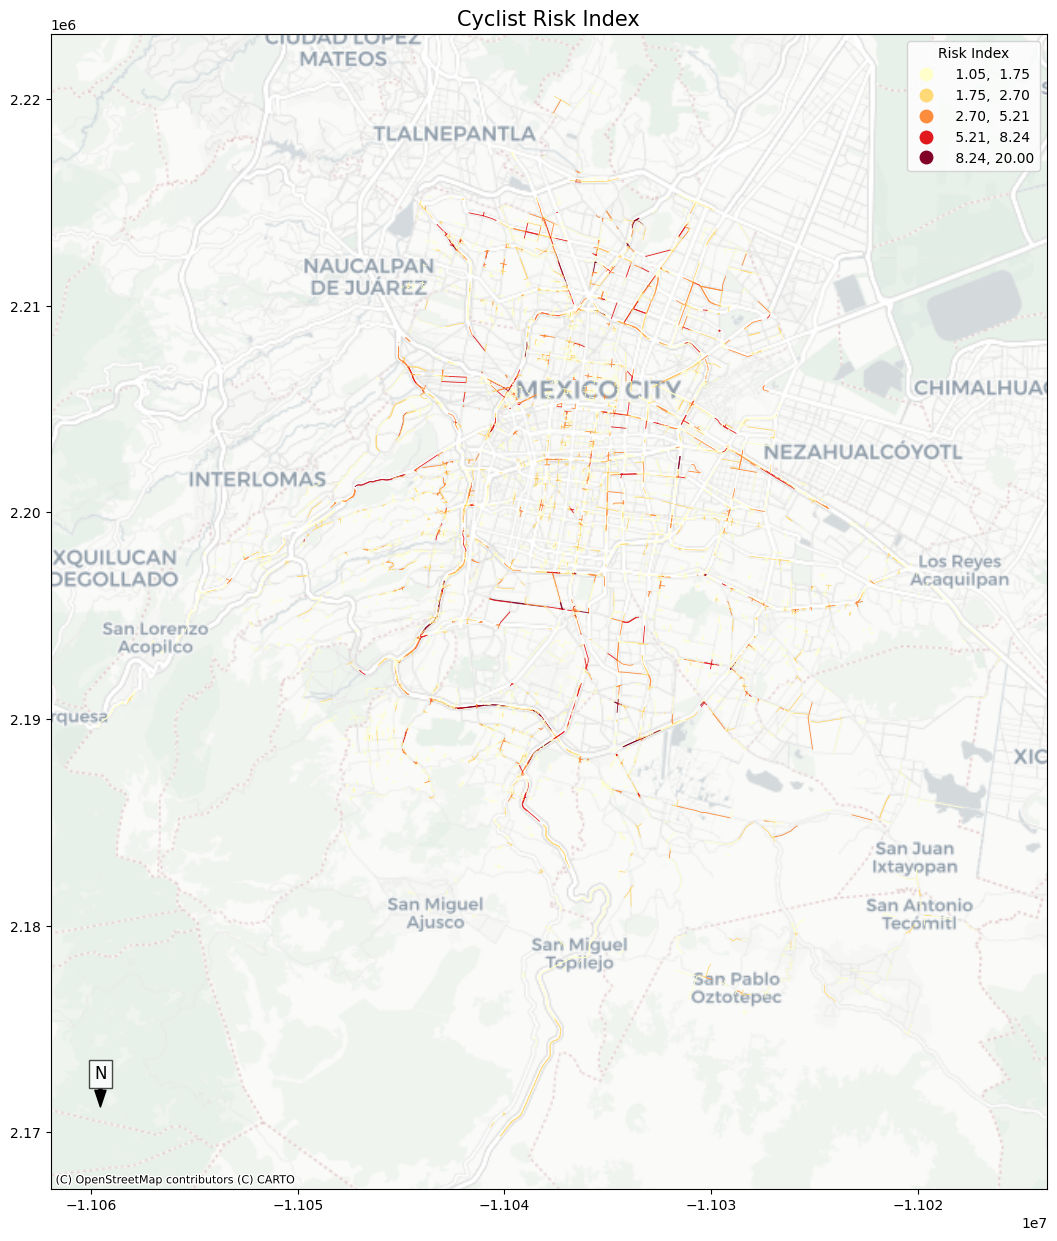

Map saved to map_final_rendered.png


In [62]:
import matplotlib.pyplot as plt
import contextily as ctx
import mapclassify
from matplotlib_scalebar.scalebar import ScaleBar # Import ScaleBar for North Arrow

fig, ax = plt.subplots(figsize=(15, 15))

# Thematic styling: Color the road lines according to their risk_index value
# using the YlOrRd colormap and NaturalBreaks classification scheme with k=5.
# Maximize line visibility by setting linewidth=4 and explicitly removing the border (edgecolor='none').
high_risk_roads.plot(
    ax=ax,
    column='risk_index',
    cmap='YlOrRd',
    scheme='NaturalBreaks',
    k=5,
    legend=True,
    linewidth=4,
    legend_kwds={'title': 'Risk Index'},
    edgecolor='none'
)

# Basemap: Add a base map using contextily with the CartoDB.Positron style.
ctx.add_basemap(ax, crs=high_risk_roads.crs, source=ctx.providers.CartoDB.Positron)

# Map elements: Add a North arrow
# You can add a North arrow using an annotation. For a more sophisticated one, you might need a custom function.
# For simplicity, here's a basic text annotation for a North arrow in the bottom-left corner.
# A more advanced North arrow might involve drawing an arrow shape.

# For simplicity, let's use a text annotation for the North arrow
# First, calculate appropriate coordinates for the arrow
x_min, y_min, x_max, y_max = ax.get_xlim()[0], ax.get_ylim()[0], ax.get_xlim()[1], ax.get_ylim()[1]
x_center = x_min + (x_max - x_min) * 0.05 # 5% from left
y_center = y_min + (y_max - y_min) * 0.05 # 5% from bottom

# Add an arrow annotation pointing upwards with 'N' above it
ax.annotate('N',
            xy=(x_center, y_center + (y_max - y_min) * 0.02), # 'N' slightly above arrow
            xytext=(x_center, y_center + (y_max - y_min) * 0.05), # Arrow tip
            arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
            ha='center', va='center', fontsize=12, color='black',
            bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="black", lw=1, alpha=0.7))


# Formatting: Add the title "Cyclist risk index" with a font size of 15, and maintain the axis coordinates by explicitly calling ax.set_axis_on().
ax.set_title('Cyclist Risk Index', fontsize=15)
ax.set_axis_on() # Ensure axes are visible

# Map export: Save the final resulting map as a PNG file named map_final_rendered.png at 300 dpi
output_map_filename = 'map_final_rendered.png'
plt.savefig(output_map_filename, dpi=300, bbox_inches='tight')

plt.show()
print(f"Map saved to {output_map_filename}")